# 04 · Récupérer des fichiers open data : les taxis de New York

Jusqu'ici, la donnée était dans une base que l'on interrogeait. Très souvent, elle arrive plutôt sous forme de **fichiers publiés sur le web** : c'est le cas de l'*open data* (données publiques, réutilisables librement). Ce notebook montre comment les récupérer **proprement**, puis les interroger en SQL.

> 🎯 **Cas d'usage**
>
> Une journaliste d'un média local new-yorkais prépare un article sur les **taxis verts** (*Green taxis*), ceux qui n'ont le droit de prendre des clients dans la rue qu'en dehors du centre de Manhattan (nord de Manhattan, Bronx, Brooklyn, Queens, Staten Island). Elle vous pose trois questions :
> 1. **combien de courses par mois** sur les 6 derniers mois publiés ?
> 2. **quelles zones de départ** sont les plus fréquentes ?
> 3. **que pèsent-ils face aux taxis jaunes** (*Yellow*) ? Sans télécharger leurs ~60 Mo par mois : le wifi de la rédaction, comme celui de la salle, est partagé.
>
> Votre mission : constituer un mini **data lake** local (un dossier organisé où l'on garde les fichiers bruts et les résultats) à partir des fichiers officiels de la ville, **traçable** et **relançable sans risque**, puis répondre en SQL avec DuckDB.

**Ce que vous allez apprendre**
- lire la page d'une source open data : motif d'URL, dictionnaire de données, conditions d'utilisation ;
- télécharger un fichier avec `requests` en contrôlant le code HTTP, la taille et l'**empreinte sha256** ;
- écrire une fonction de téléchargement **idempotente** et **atomique**, et tenir un **manifeste** ;
- interroger des fichiers CSV et Parquet **en SQL avec DuckDB**, sans les importer dans une base ;
- comprendre pourquoi **Parquet** est plus léger et plus rapide que CSV, au point de pouvoir être lu **à distance**.

**Durée indicative** : 25 minutes de parcours guidé (+ 15 minutes d'exercices).

**Prérequis** : Python de base (variables, boucles, fonctions) et un peu de SQL (`SELECT`, `GROUP BY`, `JOIN`). Une connexion internet (environ 25 Mo échangés au total, extension DuckDB comprise). Pas besoin du fichier `.env` : les données sont publiques, **aucun identifiant n'est nécessaire**.

## 1. La source : les fichiers de la TLC

La **TLC** (*Taxi & Limousine Commission*) est l'autorité qui régule les taxis et VTC de New York. Elle publie chaque mois les courses enregistrées par les taximètres sur cette page :
https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

Avant d'écrire la moindre ligne de code, on lit la page et on repère :

| Élément | Ce que dit la page |
|---|---|
| **Motif d'URL** | `https://d37ci6vzurychx.cloudfront.net/trip-data/{type}_tripdata_{AAAA-MM}.parquet`, avec `type` = `yellow`, `green`, `fhv` ou `fhvhv` (VTC type Uber/Lyft) |
| **Fréquence** | un fichier par mois et par type, publié avec environ **2 mois de retard** (le temps que tous les fournisseurs envoient leurs données) |
| **Format** | **Parquet** : format de fichier *colonnaire* et compressé, vu en cours |
| **Dictionnaire de données** | PDF [*Green Trips Data Dictionary*](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_green.pdf) : le sens de chaque colonne et de chaque code (ex. `payment_type` 1 = carte, 2 = espèces) |
| **Table des zones** | `taxi_zone_lookup.csv` : relie un numéro de zone (`LocationID`) à un *borough* (arrondissement) et à un nom de zone |
| **Conditions d'utilisation** | données publiques (NYC Open Data), réutilisables librement ; la TLC précise qu'elles lui sont transmises par les fournisseurs de taximètres et qu'elle **ne garantit pas leur exactitude**. Conditions générales : lien *Terms of use* en bas de page |

> 💡 Un **dictionnaire de données** décrit chaque colonne d'un jeu de données : nom, signification, unité, codes possibles. Gardez-le ouvert pendant l'analyse : sans lui, `payment_type = 2` ne veut rien dire.

**Les 4 réflexes du cours** pour télécharger de l'open data, appliqués dans ce notebook :
1. **Nommer et dater** chaque fichier (ici le mois est déjà dans le nom ; on date la table des zones) → sections 2 et 4 ;
2. **Vérifier la taille et l'empreinte sha256** → sections 2 et 5 ;
3. **Garder le brut tel quel** dans `data/raw/`, les résultats calculés allant dans `data/processed/` → sections 4 et 7 ;
4. **Noter la source, la licence et la date de récupération** → le manifeste, section 5.

On importe les bibliothèques utilisées dans le notebook.

In [1]:
import hashlib                   # empreintes sha256
import json                      # lire / écrire du JSON (le manifeste)
import time                      # chronomètre
from datetime import date, datetime
from pathlib import Path         # chemins de fichiers

import duckdb                    # SQL sur des fichiers
import matplotlib.pyplot as plt  # graphique
import pandas as pd              # tableaux de données
import requests                  # requêtes HTTP

On prépare les dossiers du data lake et l'adresse du serveur de la TLC. `mkdir(parents=True, exist_ok=True)` crée les dossiers s'ils n'existent pas, sans erreur s'ils existent déjà.

In [2]:
DOSSIER_DATA = Path("../data")
DOSSIER_TAXI = DOSSIER_DATA / "raw" / "nyc_taxi"   # fichiers bruts (couche « bronze »)
DOSSIER_RESULTATS = DOSSIER_DATA / "processed"     # résultats calculés (couche « gold »)
DOSSIER_TAXI.mkdir(parents=True, exist_ok=True)
DOSSIER_RESULTATS.mkdir(parents=True, exist_ok=True)

URL_BASE = "https://d37ci6vzurychx.cloudfront.net"  # serveur des fichiers de la TLC
print("Fichiers bruts :", DOSSIER_TAXI)
print("Résultats      :", DOSSIER_RESULTATS)

Fichiers bruts : ../data/raw/nyc_taxi
Résultats      : ../data/processed


## 2. Télécharger un petit fichier : la table des zones

On commence par le plus petit fichier (12 Ko) pour voir chaque étape. `requests.get(url)` envoie une requête HTTP **GET** et renvoie la réponse du serveur. Deux précautions systématiques :
- `timeout=30` : si le serveur ne répond pas en 30 secondes, on abandonne au lieu d'attendre indéfiniment ;
- `raise_for_status()` : déclenche une erreur si le **code HTTP** n'est pas un succès (403, 404, 500…), au lieu de continuer avec une page d'erreur à la place des données.

In [3]:
url_zones = f"{URL_BASE}/misc/taxi_zone_lookup.csv"

reponse = requests.get(url_zones, timeout=30)
reponse.raise_for_status()  # s'arrête ici si le serveur renvoie une erreur

print("Code HTTP :", reponse.status_code)
print("Type      :", reponse.headers["Content-Type"])
print("Taille    :", len(reponse.content), "octets")

Code HTTP : 200
Type      : text/csv
Taille    : 12331 octets


On enregistre le contenu **tel quel** (réflexe 3) avec `write_bytes` : les octets reçus sont écrits sans aucune transformation. Le nom du fichier contient la **date du jour** (réflexe 1) : la table des zones n'a pas de date dans son nom et la TLC peut la mettre à jour, on saura donc de quand date notre copie.

In [4]:
chemin_zones = DOSSIER_TAXI / f"taxi_zone_lookup_{date.today().isoformat()}.csv"
chemin_zones.write_bytes(reponse.content)
print("Fichier enregistré :", chemin_zones)

Fichier enregistré : ../data/raw/nyc_taxi/taxi_zone_lookup_2026-10-07.csv


Réflexe 2 : la taille et l'**empreinte**. Une empreinte sha256 (*hash*) est une suite de 64 caractères calculée à partir du contenu du fichier. Deux fichiers identiques ont la même empreinte ; si un seul octet change (téléchargement coupé, fichier modifié à la source), l'empreinte est complètement différente. C'est la « signature » du fichier.

On l'écrit dans une petite fonction, car on va s'en resservir.

In [5]:
def sha256_fichier(chemin):
    """Renvoie l'empreinte sha256 (64 caractères) du contenu d'un fichier."""
    return hashlib.sha256(Path(chemin).read_bytes()).hexdigest()


print("Taille :", chemin_zones.stat().st_size, "octets")
print("sha256 :", sha256_fichier(chemin_zones))

Taille : 12331 octets
sha256 : 1a99e105092230f8620f301edcca7f80d3080642ff404d28ed957d3fa222c8ed


## 3. Une fonction de téléchargement fiable

Pour les fichiers de courses, on ne va pas recopier ces lignes pour chaque mois. On écrit une fonction `telecharger(url, destination)` qui a deux qualités vues en cours (et dans le dépôt de l'enseignant `advanced-python-atut`) :

- **Idempotente** : l'exécuter 1 fois ou 10 fois donne le même résultat. Si le fichier est déjà là, on ne le retélécharge pas : on peut relancer le notebook sans gaspiller la bande passante.
- **Atomique** : le fichier final est soit complet, soit absent, **jamais à moitié écrit**. On écrit d'abord dans un fichier `….tmp`, puis on le **renomme** une fois terminé. Si la connexion coupe au milieu, il ne reste qu'un `.tmp` incomplet, que le prochain lancement réécrira.

Deux nouveautés dans le code :
- le **streaming** : avec `stream=True`, `requests` ne charge pas tout le fichier en mémoire ; `iter_content` le livre par morceaux (ici 1 Mo) que l'on écrit au fur et à mesure. Indispensable pour les gros fichiers (un mois de VTC Uber/Lyft pèse 500 Mo) ;
- `with … as reponse:` garantit que la connexion est refermée à la fin, même en cas d'erreur.

Enfin, si le serveur répond que le fichier n'existe pas (code 403 ou 404, voir section 4), la fonction affiche un message clair et renvoie `None` au lieu de planter.

In [6]:
def telecharger(url, destination):
    """Télécharge url vers destination, sauf si le fichier existe déjà.
    Renvoie le chemin du fichier, ou None si le serveur ne le fournit pas."""
    destination = Path(destination)
    if destination.exists():                       # idempotence : déjà là, on ne refait rien
        print(f"Déjà présent : {destination.name}")
        return destination
    fichier_tmp = destination.with_name(destination.name + ".tmp")
    with requests.get(url, stream=True, timeout=60) as reponse:
        if reponse.status_code in (403, 404):      # fichier absent du serveur
            print(f"⚠️ Indisponible (HTTP {reponse.status_code}) : {url}")
            return None
        reponse.raise_for_status()                 # toute autre erreur : on s'arrête
        with open(fichier_tmp, "wb") as fichier:    # "wb" : écriture d'octets
            for morceau in reponse.iter_content(chunk_size=1024 * 1024):
                fichier.write(morceau)
    fichier_tmp.rename(destination)                # atomicité : renommage une fois complet
    print(f"Téléchargé   : {destination.name} ({destination.stat().st_size / 1e6:.2f} Mo)")
    return destination

Testons-la sur la table des zones, téléchargée juste avant : la fonction ne doit **rien retélécharger** et renvoyer le chemin du fichier (affiché `PosixPath(…)` sous Linux/macOS, `WindowsPath(…)` sous Windows).

In [7]:
telecharger(url_zones, chemin_zones)

Déjà présent : taxi_zone_lookup_2026-10-07.csv


PosixPath('../data/raw/nyc_taxi/taxi_zone_lookup_2026-10-07.csv')

## 4. Constituer le mini data lake : 6 mois de taxis verts

**Quels mois sont publiés ?** Une requête HTTP **HEAD** demande seulement l'en-tête de la réponse (code HTTP, taille, date de modification), sans le contenu : idéal pour tester une URL sans rien télécharger.

In [8]:
for mois in ["2026-07", "2026-08", "2026-09", "2026-10"]:
    url = f"{URL_BASE}/trip-data/green_tripdata_{mois}.parquet"
    reponse = requests.head(url, timeout=30)
    if reponse.status_code == 200:
        taille_mo = int(reponse.headers["Content-Length"]) / 1e6
        print(f"{mois} : publié ({taille_mo:.2f} Mo)")
    else:
        print(f"{mois} : pas disponible (HTTP {reponse.status_code})")

2026-07 : publié (1.02 Mo)


2026-08 : publié (1.01 Mo)


2026-09 : pas disponible (HTTP 403)


2026-10 : pas disponible (HTTP 403)


Au moment de la rédaction (octobre 2026), le dernier mois publié est **août 2026** : c'est le retard d'environ 2 mois annoncé sur la page. Les 6 derniers mois disponibles vont donc de **mars à août 2026**.

> ⚠️ Pour un fichier absent, ce serveur répond **403 Forbidden** (« accès refusé ») et non **404 Not Found**. Les fichiers sont stockés sur Amazon S3 et servis par CloudFront, qui refusent de dire si un fichier existe quand on n'a pas le droit de lister leur contenu. Retenez que, selon le serveur, « fichier absent » peut s'afficher 403 **ou** 404 : c'est pourquoi `telecharger` traite les deux.

On télécharge les 6 mois avec une boucle. On garde le **nom d'origine** des fichiers : il contient déjà le mois (réflexe 1).

In [9]:
MOIS_GREEN = ["2026-03", "2026-04", "2026-05", "2026-06", "2026-07", "2026-08"]

fichiers_green = []
for mois in MOIS_GREEN:
    url = f"{URL_BASE}/trip-data/green_tripdata_{mois}.parquet"
    chemin = telecharger(url, DOSSIER_TAXI / f"green_tripdata_{mois}.parquet")
    if chemin is not None:
        fichiers_green.append(chemin)

print(len(fichiers_green), "fichiers Green dans le data lake")

Déjà présent : green_tripdata_2026-03.parquet
Déjà présent : green_tripdata_2026-04.parquet
Déjà présent : green_tripdata_2026-05.parquet
Déjà présent : green_tripdata_2026-06.parquet
Déjà présent : green_tripdata_2026-07.parquet
Déjà présent : green_tripdata_2026-08.parquet
6 fichiers Green dans le data lake


**Idempotence en action.** Relançons exactement la même boucle (c'est ce qui se passe quand vous relancez la cellule ou tout le notebook) : rien n'est retéléchargé.

In [10]:
for mois in MOIS_GREEN:
    url = f"{URL_BASE}/trip-data/green_tripdata_{mois}.parquet"
    telecharger(url, DOSSIER_TAXI / f"green_tripdata_{mois}.parquet")

Déjà présent : green_tripdata_2026-03.parquet
Déjà présent : green_tripdata_2026-04.parquet
Déjà présent : green_tripdata_2026-05.parquet
Déjà présent : green_tripdata_2026-06.parquet
Déjà présent : green_tripdata_2026-07.parquet
Déjà présent : green_tripdata_2026-08.parquet


**Et un mois pas encore publié ?** Le mois en cours ne l'est jamais (il n'est pas fini !). La fonction affiche un message clair, renvoie `None`, et **aucun fichier** n'est créé.

In [11]:
mois_courant = date.today().strftime("%Y-%m")   # ex. "2026-10"
url_courant = f"{URL_BASE}/trip-data/green_tripdata_{mois_courant}.parquet"
resultat = telecharger(url_courant, DOSSIER_TAXI / f"green_tripdata_{mois_courant}.parquet")

print("Valeur renvoyée :", resultat)

⚠️ Indisponible (HTTP 403) : https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2026-10.parquet
Valeur renvoyée : None


## 5. Le manifeste : la carte d'identité des fichiers

Un **manifeste** est un petit fichier (ici en JSON) qui décrit chaque fichier du data lake : d'où il vient (`url`, `source`), ce qu'il contient (`taille_octets`, `sha256`), quand on l'a récupéré (`date_recuperation`) et sous quelles conditions (`licence`). Dans six mois, n'importe qui pourra savoir d'où viennent les chiffres de l'article, et vérifier que les fichiers n'ont pas été modifiés (exercice 2).

La date de récupération est la date d'écriture du fichier sur le disque (`st_mtime`) : comme `telecharger` ne réécrit jamais un fichier existant, c'est bien la date du téléchargement.

In [12]:
def entree_manifeste(url, chemin):
    """Décrit un fichier téléchargé : provenance, taille, empreinte, date, licence."""
    date_ecriture = datetime.fromtimestamp(chemin.stat().st_mtime)
    return {
        "url": url,
        "fichier": chemin.name,
        "taille_octets": chemin.stat().st_size,
        "sha256": sha256_fichier(chemin),
        "date_recuperation": date_ecriture.isoformat(timespec="seconds"),
        "source": "NYC Taxi & Limousine Commission (TLC) - https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page",
        "licence": "Données publiques NYC Open Data : réutilisation libre, sans garantie d'exactitude",
    }

On décrit la table des zones et les 6 fichiers Green, puis on écrit le tout dans `manifest.json` (`indent=2` pour qu'il soit lisible, `ensure_ascii=False` pour garder les accents).

In [13]:
manifeste = [entree_manifeste(url_zones, chemin_zones)]
for chemin in fichiers_green:
    manifeste.append(entree_manifeste(f"{URL_BASE}/trip-data/{chemin.name}", chemin))

chemin_manifeste = DOSSIER_TAXI / "manifest.json"
chemin_manifeste.write_text(json.dumps(manifeste, indent=2, ensure_ascii=False), encoding="utf-8")
print(len(manifeste), "fichiers décrits dans", chemin_manifeste)
print(json.dumps(manifeste[-1], indent=2, ensure_ascii=False))   # la dernière entrée

7 fichiers décrits dans ../data/raw/nyc_taxi/manifest.json
{
  "url": "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2026-08.parquet",
  "fichier": "green_tripdata_2026-08.parquet",
  "taille_octets": 1007530,
  "sha256": "73539b4c19d1fc7e00a3809b09f0c1704283cff50398a022d9a01282c310e538",
  "date_recuperation": "2026-10-07T13:21:58",
  "source": "NYC Taxi & Limousine Commission (TLC) - https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page",
  "licence": "Données publiques NYC Open Data : réutilisation libre, sans garantie d'exactitude"
}


Vue d'ensemble du data lake, sous forme de tableau :

In [14]:
pd.DataFrame(manifeste)[["fichier", "taille_octets", "date_recuperation", "sha256"]]

,fichier,taille_octets,date_recuperation,sha256
0,taxi_zone_lookup_2026-10-07.csv,12331,2026-10-07T13:57:00,1a99e105092230f8620f301edcca7f80d3080642ff404d...
1,green_tripdata_2026-03.parquet,1082530,2026-10-07T13:21:50,60c8bdfc0aa7826a2d6d2a6cca0f0e0dcb2d8aa7336212...
2,green_tripdata_2026-04.parquet,1075896,2026-10-07T13:21:52,e8dd2a0afde3fe8be942dd638fe1d946f8edbe5b377cf6...
3,green_tripdata_2026-05.parquet,1102947,2026-10-07T13:21:53,15ff57840a1103d49298ad244492730ca4236b4de0d275...
4,green_tripdata_2026-06.parquet,1075836,2026-10-07T13:21:55,08e214dcb285cb5cecb183635080e817ca24f0c6491eb7...
5,green_tripdata_2026-07.parquet,1018250,2026-10-07T13:21:56,1e01084ab77643cc94e53ad7c30163dd7e8ef0be7b5bbf...
6,green_tripdata_2026-08.parquet,1007530,2026-10-07T13:21:58,73539b4c19d1fc7e00a3809b09f0c1704283cff50398a0...


## 6. Lire les fichiers avec pandas et repérer les anomalies

`pd.read_csv` lit un CSV, `pd.read_parquet` lit un Parquet. Commençons par la table des zones.

In [15]:
zones = pd.read_csv(chemin_zones)
print("Table des zones :", zones.shape[0], "lignes,", zones.shape[1], "colonnes")
zones.head()

Table des zones : 265 lignes, 4 colonnes


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


265 lignes : 262 zones réparties dans les 5 *boroughs* de New York (Manhattan, Brooklyn, Queens, Bronx, Staten Island), plus l'aéroport de Newark (`EWR`, dans l'État voisin du New Jersey) et deux lignes spéciales, `Unknown` (zone 264, inconnue) et `N/A` (zone 265, hors de New York).

Lisons maintenant un mois de courses : **août 2026**.

In [16]:
courses_aout = pd.read_parquet(DOSSIER_TAXI / "green_tripdata_2026-08.parquet")
print("Courses d'août 2026 :", courses_aout.shape[0], "lignes,", courses_aout.shape[1], "colonnes")
print(list(courses_aout.columns))

Courses d'août 2026 : 40687 lignes, 22 colonnes
['VendorID', 'lpep_pickup_datetime', 'lpep_dropoff_datetime', 'store_and_fwd_flag', 'RatecodeID', 'PULocationID', 'DOLocationID', 'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'ehail_fee', 'improvement_surcharge', 'total_amount', 'payment_type', 'trip_type', 'congestion_surcharge', 'cbd_congestion_fee', 'request_source']


Le **dictionnaire de données** nous dit comment lire les colonnes principales :
- `lpep_pickup_datetime` / `lpep_dropoff_datetime` : début / fin de la course, c'est-à-dire mise en marche / arrêt du taximètre (`lpep` vient de *LPEP*, le programme qui équipe les taxis verts en taximètres connectés ; chez les jaunes, c'est *TPEP*, d'où `tpep_pickup_datetime`) ;
- `PULocationID` / `DOLocationID` : zone de prise en charge (*pick-up*) / de dépose (*drop-off*), à relier à la table des zones ;
- `trip_distance` en **miles** ; `fare_amount` (prix au compteur), `tip_amount` (pourboire) et `total_amount` (total payé) en **dollars** ;
- `payment_type` : 1 = carte bancaire, 2 = espèces, 3 = gratuit, 4 = litige…

Affichons ces colonnes pour les premières courses.

In [17]:
colonnes_utiles = ["lpep_pickup_datetime", "PULocationID", "DOLocationID",
                   "trip_distance", "fare_amount", "tip_amount", "total_amount", "payment_type"]
courses_aout[colonnes_utiles].head()

,lpep_pickup_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,tip_amount,total_amount,payment_type
0,2026-08-01 00:50:34,83,82,0.53,5.8,1.50,9.80,1.0
1,2026-08-01 00:19:16,112,148,3.70,45.0,0.00,49.50,1.0
2,2026-08-01 00:34:22,66,90,4.32,25.4,6.28,37.68,1.0
3,2026-08-01 00:49:24,130,256,11.39,49.2,10.34,62.04,1.0
4,2026-07-31 23:52:23,75,41,0.66,5.8,1.70,10.00,1.0


**Repérer les anomalies.** Un fichier officiel n'est pas un fichier parfait. Première vérification : toutes les courses du fichier d'août commencent-elles bien en août 2026 ?

In [18]:
debut_mois = pd.Timestamp("2026-08-01")
fin_mois = pd.Timestamp("2026-09-01")
dates_depart = courses_aout["lpep_pickup_datetime"]
# | signifie « ou » : départ avant le 1er août OU à partir du 1er septembre
hors_mois = courses_aout[(dates_depart < debut_mois) | (dates_depart >= fin_mois)]

print("Courses dont le départ n'est pas en août 2026 :", len(hors_mois))
colonnes_a_voir = ["lpep_pickup_datetime", "lpep_dropoff_datetime", "trip_distance", "total_amount"]
hors_mois[colonnes_a_voir].sort_values("lpep_pickup_datetime").head()

Courses dont le départ n'est pas en août 2026 : 14


,lpep_pickup_datetime,lpep_dropoff_datetime,trip_distance,total_amount
18542,2008-12-31 23:06:23,2009-01-01 20:36:50,2.80,23.17
25591,2009-01-01 12:02:35,2009-01-01 12:45:35,9.97,56.30
119,2026-07-25 21:42:42,2026-07-25 21:42:44,0.00,33.80
133,2026-07-25 22:14:34,2026-07-25 22:41:10,14.27,75.56
1976,2026-07-27 21:12:28,2026-07-27 21:24:10,4.02,26.60


Des courses datées de… **2008** et **2009** (l'horloge du taximètre était sans doute mal réglée), et quelques courses de fin juillet transmises en retard. Deuxième et troisième vérifications : des montants négatifs ? des distances nulles ?

In [19]:
nb_courses = len(courses_aout)
nb_negatifs = (courses_aout["total_amount"] < 0).sum()
nb_distance_nulle = (courses_aout["trip_distance"] == 0).sum()
nb_paiement_vide = courses_aout["payment_type"].isna().sum()

print(f"Montant total négatif : {nb_negatifs} ({nb_negatifs / nb_courses:.1%})")
print(f"Distance nulle        : {nb_distance_nulle} ({nb_distance_nulle / nb_courses:.1%})")
print(f"Type de paiement vide : {nb_paiement_vide} ({nb_paiement_vide / nb_courses:.1%})")

Montant total négatif : 159 (0.4%)
Distance nulle        : 1800 (4.4%)
Type de paiement vide : 6313 (15.5%)


Les montants négatifs correspondent probablement à des corrections ou remboursements enregistrés comme des courses « en moins » ; les distances nulles à des courses annulées sur place ou à des taximètres défaillants. Les types de paiement vides semblent venir de courses **commandées par application**, pour lesquelles plusieurs champs ne sont pas remplis (nombre de passagers, code tarifaire…) : la colonne `request_source`, apparue en juin 2026 et absente du dictionnaire, n'est remplie que pour des courses de ce genre (ex. `HV0005`, le numéro de licence de Lyft).

Ces cases vides expliquent aussi pourquoi pandas affiche `payment_type` en `1.0` au lieu de `1` : une colonne de nombres entiers qui contient des cases vides est stockée en nombres décimaux.

> 💡 On **ne corrige pas le fichier brut** (réflexe 3) : on garde ces anomalies en tête et on les **filtre au moment de l'analyse**. Dans un vrai projet, un fichier nettoyé irait dans une couche intermédiaire (« silver »).

## 7. Interroger les fichiers en SQL avec DuckDB

**DuckDB** est un SGBD **analytique** (OLAP, vu en cours) qui tient dans une simple bibliothèque Python : pas de serveur, pas de compte, pas de mot de passe. Sa particularité : il exécute du SQL **directement sur des fichiers** CSV ou Parquet, sans les importer au préalable.

`duckdb.connect()` sans argument crée une base **en mémoire** : rien n'est écrit sur le disque, elle sert juste à calculer. `con.sql(...)` exécute une requête et `.df()` transforme le résultat en tableau pandas.

In [20]:
con = duckdb.connect()                       # base temporaire, en mémoire
con.sql("SET enable_progress_bar = false")   # pas de barre de progression dans les sorties

con.sql("SELECT count(*) AS nb_courses FROM '../data/raw/nyc_taxi/green_tripdata_2026-08.parquet'").df()

,nb_courses
0,40687


Même nombre de lignes qu'avec pandas : la requête a lu le fichier Parquet directement, comme si c'était une table.

**Plusieurs fichiers d'un coup.** Dans un chemin, le caractère `*` signifie « n'importe quels caractères » (on parle de motif ou *glob*) : `green_tripdata_*.parquet` désigne **tous** les fichiers Green du dossier, que DuckDB lit comme une seule table.

In [21]:
con.sql("SELECT count(*) AS nb_courses FROM '../data/raw/nyc_taxi/green_tripdata_*.parquet'").df()

,nb_courses
0,259469


> 💡 Si vous ajoutez un fichier dans le dossier (exercice 1), le motif le prend en compte automatiquement : relancée après l'exercice 1, cette cellule affichera environ 46 000 courses de plus.

> ⚠️ Les fichiers n'ont pas tous exactement les mêmes colonnes : `request_source` n'apparaît qu'à partir de juin 2026. Par défaut, DuckDB garde les colonnes du **premier** fichier ; `read_parquet('…', union_by_name = true)` rassemblerait toutes les colonnes par leur nom. Ce n'est pas gênant ici, nous n'utilisons pas cette colonne.

**Deux vues pour simplifier la suite.** Une **vue** est une requête enregistrée sous un nom (comme `v_moyennes_eleves` dans PostgreSQL) : les données restent dans les fichiers, rien n'est copié. La vue `courses_green` ne garde que les départs de **mars à août 2026**, ce qui écarte les dates aberrantes repérées en section 6. La vue `zones` pointe vers notre fichier CSV.

In [22]:
con.sql("""
    CREATE OR REPLACE VIEW courses_green AS
    SELECT *
    FROM '../data/raw/nyc_taxi/green_tripdata_*.parquet'
    WHERE lpep_pickup_datetime >= '2026-03-01'
      AND lpep_pickup_datetime <  '2026-09-01'
""")
con.sql(f"CREATE OR REPLACE VIEW zones AS SELECT * FROM '{chemin_zones}'")
print("Vues créées : courses_green et zones")

Vues créées : courses_green et zones


**Question 1 : combien de courses par mois ?** `strftime(date, '%Y-%m')` transforme une date en texte « année-mois » (ex. `2026-08`), ce qui permet de regrouper les courses par mois.

In [23]:
courses_par_mois = con.sql("""
    SELECT strftime(lpep_pickup_datetime, '%Y-%m') AS mois,
           count(*)                                AS nb_courses,
           round(avg(total_amount), 2)             AS montant_moyen
    FROM courses_green
    GROUP BY mois
    ORDER BY mois
""").df()
courses_par_mois

,mois,nb_courses,montant_moyen
0,2026-03,44200,24.91
1,2026-04,44243,25.41
2,2026-05,44925,25.93
3,2026-06,44156,26.27
4,2026-07,41249,26.23
5,2026-08,40678,26.58


Environ **40 000 à 45 000 courses par mois**, avec un léger recul en juillet et août (sans doute l'effet des vacances d'été). Le montant moyen d'une course est d'environ 25 à 27 dollars.

**Question 2 : quelles zones de départ ?** Les courses ne contiennent qu'un numéro de zone (`PULocationID`). Une **jointure** (`JOIN`) relie chaque course à la ligne de la table des zones qui porte le même numéro (`LocationID`) — exactement comme entre deux tables d'une base relationnelle, sauf qu'ici l'une est un fichier Parquet et l'autre un CSV. On garde la requête dans une variable, car on va la réutiliser.

In [24]:
requete_top10 = """
    SELECT z.Borough  AS borough,
           z.Zone     AS zone,
           count(*)   AS nb_courses
    FROM courses_green AS c
    JOIN zones AS z ON c.PULocationID = z.LocationID
    GROUP BY z.Borough, z.Zone
    ORDER BY nb_courses DESC
    LIMIT 10
"""
top10_zones = con.sql(requete_top10).df()
top10_zones

,borough,zone,nb_courses
0,Manhattan,East Harlem North,68122
1,Manhattan,East Harlem South,32986
2,Queens,Forest Hills,12292
3,Manhattan,Central Park,10304
4,Manhattan,Morningside Heights,9664
5,Queens,Elmhurst,9290
6,Brooklyn,Downtown Brooklyn/MetroTech,8633
7,Manhattan,Central Harlem,8320
8,Queens,Jamaica,7204
9,Brooklyn,Fort Greene,6074


**East Harlem** (nord de Manhattan) domine largement : ses deux zones, Nord et Sud, totalisent environ 101 000 départs sur 259 000, soit près de **40 %**. C'est logique : les taxis verts n'ont pas le droit de prendre des clients dans la rue au centre et au sud de Manhattan, ils se concentrent donc juste au-dessus de cette limite.

**Enregistrer le résultat « gold ».** Dans l'organisation en couches vue en cours, `data/raw/` est la couche **bronze** (le brut) ; `data/processed/` accueille les fichiers retravaillés : des tables nettoyées (couche **silver**, comme au notebook 02) ou, comme ici, des résultats **gold** prêts à l'emploi (pour un graphique, un tableau de bord, l'article). `COPY (requête) TO 'fichier' (FORMAT parquet)` écrit le résultat d'une requête dans un fichier. Le nom indique la période couverte.

In [25]:
chemin_gold = DOSSIER_RESULTATS / "top10_zones_depart_green_2026-03_2026-08.parquet"
con.sql(f"COPY ({requete_top10}) TO '{chemin_gold}' (FORMAT parquet)")

print("Résultat enregistré :", chemin_gold)
print("Relecture :", pd.read_parquet(chemin_gold).shape[0], "lignes")

Résultat enregistré : ../data/processed/top10_zones_depart_green_2026-03_2026-08.parquet
Relecture : 10 lignes


## 8. CSV ou Parquet ? La démo du cours

Reprenons la démo du cours : convertir un fichier, puis lancer **la même requête** sur les deux formats et comparer la **taille** et le **temps**. On convertit août 2026 en CSV avec `COPY … TO … (HEADER)` (`HEADER` = écrire la ligne des noms de colonnes). La copie va dans `processed/` : ce n'est plus le fichier brut d'origine (réflexe 3).

In [26]:
fichier_parquet = DOSSIER_TAXI / "green_tripdata_2026-08.parquet"
fichier_csv = DOSSIER_RESULTATS / "green_tripdata_2026-08.csv"
con.sql(f"COPY (SELECT * FROM '{fichier_parquet}') TO '{fichier_csv}' (HEADER)")

print(f"Parquet : {fichier_parquet.stat().st_size / 1e6:.2f} Mo")
print(f"CSV     : {fichier_csv.stat().st_size / 1e6:.2f} Mo")

Parquet : 1.01 Mo
CSV     : 4.23 Mo


Maintenant, le temps. `time.perf_counter()` sert de chronomètre : on note l'heure avant et après la requête, la différence est la durée.

In [27]:
for fichier in [fichier_csv, fichier_parquet]:
    debut = time.perf_counter()
    con.sql(f"""
        SELECT payment_type, count(*) AS nb, avg(total_amount) AS montant_moyen
        FROM '{fichier}'
        GROUP BY payment_type
    """).df()                                 # .df() force le calcul complet
    duree_ms = (time.perf_counter() - debut) * 1000
    print(f"{fichier.name} : {duree_ms:.1f} ms")

green_tripdata_2026-08.csv : 206.5 ms
green_tripdata_2026-08.parquet : 4.3 ms


Le Parquet est environ **4 fois plus petit** et la requête y est des **dizaines de fois plus rapide** (les temps exacts varient d'une machine à l'autre ; c'est l'ordre de grandeur qui compte). Pourquoi ?
- **CSV** = du texte, ligne par ligne : pour calculer une moyenne, DuckDB doit lire **toutes** les colonnes de toutes les lignes, découper le texte et deviner les types (nombre ? date ?).
- **Parquet** = **colonnaire** et compressé : les valeurs d'une même colonne sont rangées ensemble, avec leur type. DuckDB ne lit que les 2 colonnes utiles (`payment_type`, `total_amount`) sur 22.

## 9. Les taxis jaunes à distance, sans téléchargement

Un mois de taxis jaunes pèse environ **60 Mo** (plus de 3 millions de courses). 30 étudiants × 60 Mo = près de 2 Go sur le wifi de la salle… Or DuckDB sait interroger un fichier Parquet **directement sur le serveur** : on lui donne l'URL à la place d'un chemin local. On prend le même mois que notre dernier mois Green (août 2026) pour comparer.

> ⚠️ La première requête distante installe automatiquement l'extension `httpfs` de DuckDB (téléchargement unique de 7 à 10 Mo selon le système ; c'est déjà fait si vous avez exécuté le notebook 00). Chaque requête distante prend ensuite quelques secondes : c'est normal, chaque morceau de fichier est demandé au serveur par internet.

`.fetchone()` renvoie la première ligne du résultat (un *tuple*) ; `[0]` en prend la première valeur.

In [28]:
MOIS_YELLOW = "2026-08"
url_yellow = f"{URL_BASE}/trip-data/yellow_tripdata_{MOIS_YELLOW}.parquet"

debut = time.perf_counter()
nb_yellow = con.sql(f"SELECT count(*) FROM '{url_yellow}'").fetchone()[0]
print(f"Courses Yellow en {MOIS_YELLOW} : {nb_yellow}  (lu en {time.perf_counter() - debut:.1f} s)")
print(f"Courses Green  en {MOIS_YELLOW} : {len(courses_aout)}")
print(f"→ environ {nb_yellow / len(courses_aout):.0f} fois plus de courses en taxi jaune")

Courses Yellow en 2026-08 : 3336716  (lu en 0.6 s)
Courses Green  en 2026-08 : 40687
→ environ 82 fois plus de courses en taxi jaune


**Comment paie-t-on dans les taxis jaunes ?** Nombre de courses et montant moyen par type de paiement, toujours sans télécharger le fichier. On ajoute ensuite le libellé de chaque code, recopié du dictionnaire de données.

In [29]:
paiements_yellow = con.sql(f"""
    SELECT payment_type,
           count(*)                    AS nb_courses,
           round(avg(total_amount), 2) AS montant_moyen
    FROM '{url_yellow}'
    GROUP BY payment_type
    ORDER BY nb_courses DESC
""").df()

TYPES_PAIEMENT = {0: "Flex Fare / non renseigné", 1: "Carte bancaire", 2: "Espèces",
                  3: "Gratuit", 4: "Litige", 5: "Inconnu", 6: "Course annulée"}
paiements_yellow["libelle"] = paiements_yellow["payment_type"].map(TYPES_PAIEMENT)
paiements_yellow

,payment_type,nb_courses,montant_moyen,libelle
0,1,2052104,30.21,Carte bancaire
1,0,921181,31.90,Flex Fare / non renseigné
2,2,329477,26.35,Espèces
3,4,23557,5.47,Litige
4,3,10397,14.38,Gratuit


La carte bancaire domine largement, et les courses payées par carte rapportent davantage en moyenne que celles payées en espèces (le pourboire par carte est inclus dans le total).

> 💡 Le dictionnaire décrit le code 0 comme *Flex Fare trip* (prix fixé à l'avance via une application), mais toutes ces lignes ont aussi le nombre de passagers, le code tarifaire (`RatecodeID`) et les frais d'aéroport vides : prudence, on les lit comme « non renseigné ». Dans les fichiers Green, les courses de ce genre ont un `payment_type` **vide** (`NULL`, section 6) : deux fichiers d'une même source ne codent pas toujours une valeur manquante de la même façon.

**Pourquoi la lecture à distance est-elle possible ?** Deux ingrédients :
1. **Les requêtes HTTP partielles.** Un client peut demander au serveur seulement une **plage d'octets** du fichier (en-tête `Range: bytes=début-fin`). Le serveur répond alors `206 Partial Content` au lieu de `200`. Essayons de demander les 4 premiers octets :

In [30]:
reponse = requests.get(url_yellow, headers={"Range": "bytes=0-3"}, timeout=30)

print("Code HTTP       :", reponse.status_code)              # 206 = contenu partiel
print("Octets reçus    :", reponse.content)                  # b'PAR1' : signature d'un fichier Parquet
print("Plage / total   :", reponse.headers["Content-Range"])

Code HTTP       : 206
Octets reçus    : b'PAR1'
Plage / total   : bytes 0-3/59043961


2. **Le format Parquet est colonnaire**, et la fin du fichier contient un « sommaire » (les **métadonnées**) : nombre de lignes, colonnes, et position exacte de chaque colonne dans le fichier. DuckDB lit d'abord ce sommaire, puis **seulement les octets des colonnes utiles**. Pour `count(*)`, le sommaire suffit : d'où la rapidité de la première requête.

La fonction `parquet_metadata` de DuckDB lit ce sommaire. Calculons la place occupée par chaque colonne, et la part réellement lue par notre requête sur les paiements :

In [31]:
taille_colonnes = con.sql(f"""
    SELECT path_in_schema AS colonne,
           sum(total_compressed_size) / 1e6 AS taille_mo
    FROM parquet_metadata('{url_yellow}')
    GROUP BY colonne
""").df()

colonnes_lues = taille_colonnes[taille_colonnes["colonne"].isin(["payment_type", "total_amount"])]
print(f"Fichier complet                     : {taille_colonnes['taille_mo'].sum():.1f} Mo")
print(f"Colonnes lues (payment_type, total) : {colonnes_lues['taille_mo'].sum():.1f} Mo")

Fichier complet                     : 59.0 Mo
Colonnes lues (payment_type, total) : 6.1 Mo


Notre requête sur les paiements n'a eu besoin que d'environ **un dixième du fichier**. Avec un CSV, impossible : il aurait fallu tout télécharger.

**Téléchargement complet (optionnel).** Si vous voulez quand même le fichier entier (chez vous, pas en salle !), passez la variable ci-dessous à `True` : la fonction `telecharger` s'en charge, de façon idempotente et atomique.

In [32]:
TELECHARGER_YELLOW = False   # True = télécharger les ~60 Mo (à éviter en salle de TP)

if TELECHARGER_YELLOW:
    telecharger(url_yellow, DOSSIER_TAXI / f"yellow_tripdata_{MOIS_YELLOW}.parquet")
else:
    print("Téléchargement complet des Yellow désactivé (TELECHARGER_YELLOW = False).")

Téléchargement complet des Yellow désactivé (TELECHARGER_YELLOW = False).


## 10. Visualiser : les courses Green par mois

Un diagramme en barres à partir du tableau `courses_par_mois` calculé en section 7. `bar_label` écrit la valeur au-dessus de chaque barre.

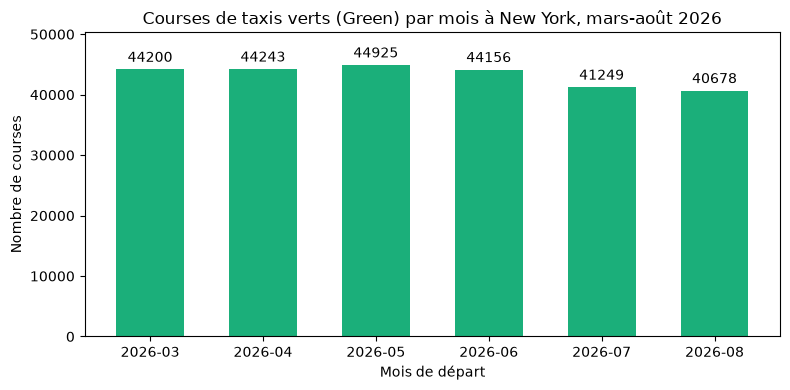

In [33]:
fig, ax = plt.subplots(figsize=(8, 4))
barres = ax.bar(courses_par_mois["mois"], courses_par_mois["nb_courses"], color="#1baf7a", width=0.6)
ax.bar_label(barres, padding=3)
ax.set_title("Courses de taxis verts (Green) par mois à New York, mars-août 2026")
ax.set_xlabel("Mois de départ")
ax.set_ylabel("Nombre de courses")
ax.margins(y=0.12)                   # un peu de place au-dessus des barres pour les valeurs
plt.tight_layout()
plt.show()

L'axe vertical part de zéro : la baisse de l'été est réelle mais modeste (environ −9 % entre mai et août).

## 11. Exercices

### ✍️ Exercice 1 — Un mois de plus, sans doublon

La journaliste veut comparer avec l'été précédent. Téléchargez le fichier Green d'**août 2025** avec la fonction `telecharger`, en l'appelant **deux fois de suite** : le second appel ne doit rien retélécharger. Comptez ensuite ses courses avec DuckDB et calculez l'évolution entre août 2025 et août 2026.

In [34]:
# ✅ Solution
url_2025 = f"{URL_BASE}/trip-data/green_tripdata_2025-08.parquet"
chemin_2025 = DOSSIER_TAXI / "green_tripdata_2025-08.parquet"
telecharger(url_2025, chemin_2025)
telecharger(url_2025, chemin_2025)   # 2e appel : « Déjà présent »

nb_2025 = con.sql(f"SELECT count(*) FROM '{chemin_2025}'").fetchone()[0]
nb_2026 = len(courses_aout)
print(f"Août 2025 : {nb_2025} courses ; août 2026 : {nb_2026} courses")
print(f"Évolution sur un an : {(nb_2026 - nb_2025) / nb_2025:+.1%}")

Téléchargé   : green_tripdata_2025-08.parquet (1.15 Mo)
Déjà présent : green_tripdata_2025-08.parquet
Août 2025 : 46306 courses ; août 2026 : 40687 courses
Évolution sur un an : -12.1%


> 💡 Ce nouveau fichier correspond au motif `green_tripdata_*.parquet` : DuckDB le verra désormais. La vue `courses_green` n'est pas affectée, car elle ne garde que les départs de mars à août 2026.

### ✍️ Exercice 2 — Le fichier a-t-il changé ?

Relisez `manifest.json` et, pour chaque fichier listé, recalculez son empreinte sha256 avec `sha256_fichier`, puis comparez-la à celle du manifeste. Affichez « OK » ou « MODIFIÉ » pour chaque fichier.

In [35]:
# ✅ Solution
manifeste_lu = json.loads(chemin_manifeste.read_text(encoding="utf-8"))

for entree in manifeste_lu:
    empreinte = sha256_fichier(DOSSIER_TAXI / entree["fichier"])
    if empreinte == entree["sha256"]:
        statut = "OK"
    else:
        statut = "MODIFIÉ"
    print(f"{entree['fichier']:40} {statut}")

taxi_zone_lookup_2026-10-07.csv          OK
green_tripdata_2026-03.parquet           OK
green_tripdata_2026-04.parquet           OK
green_tripdata_2026-05.parquet           OK
green_tripdata_2026-06.parquet           OK
green_tripdata_2026-07.parquet           OK
green_tripdata_2026-08.parquet           OK


### ✍️ Exercice 3 — Pourboire moyen par borough

Pour chaque borough de **départ**, calculez avec DuckDB le nombre de courses et le pourboire moyen (`tip_amount`), en utilisant les vues `courses_green` et `zones`. D'après le dictionnaire, seuls les pourboires **payés par carte** sont enregistrés (`payment_type = 1`) : ne gardez que ces courses. Que pensez-vous de la ligne `EWR` ?

In [36]:
# ✅ Solution
con.sql("""
    SELECT z.Borough                     AS borough,
           count(*)                      AS nb_courses,
           round(avg(c.tip_amount), 2)   AS pourboire_moyen
    FROM courses_green AS c
    JOIN zones AS z ON c.PULocationID = z.LocationID
    WHERE c.payment_type = 1           -- carte bancaire uniquement
    GROUP BY z.Borough
    ORDER BY nb_courses DESC
""").df()

,borough,nb_courses,pourboire_moyen
0,Manhattan,110279,3.66
1,Queens,34447,4.08
2,Brooklyn,22848,4.56
3,Bronx,1394,7.65
4,Unknown,494,4.29
5,N/A,131,6.27
6,Staten Island,26,3.36
7,EWR,4,45.46


> 💡 La ligne `EWR` (aéroport de Newark) affiche un pourboire moyen énorme… calculé sur **4 courses** seulement : une moyenne sur si peu de lignes ne veut rien dire. Regardez toujours l'**effectif** à côté d'une moyenne. Les lignes `Unknown` et `N/A` regroupent les zones 264 et 265 (zone inconnue, hors de New York).

### ✍️ Exercice 4 — Taxis jaunes à distance : les courses depuis l'aéroport

La colonne `Airport_fee` (frais d'aéroport) n'est facturée que pour les prises en charge aux aéroports LaGuardia et JFK. **Sans télécharger** le fichier Yellow d'août 2026, comptez les courses avec `Airport_fee > 0` et calculez leur part du total.

Bonus : combien de courses ont un `Airport_fee` **renseigné** (non vide) ? Qu'en concluez-vous ? Indice : `count(colonne)` ne compte que les valeurs non vides, alors que `count(*)` compte toutes les lignes.

In [37]:
# ✅ Solution
nb_aeroport = con.sql(f"SELECT count(*) FROM '{url_yellow}' WHERE Airport_fee > 0").fetchone()[0]
# count(Airport_fee) ne compte que les lignes où Airport_fee n'est pas vide
nb_renseigne = con.sql(f"SELECT count(Airport_fee) FROM '{url_yellow}'").fetchone()[0]

print(f"Courses Yellow avec frais d'aéroport : {nb_aeroport}")
print(f"Part du total                        : {nb_aeroport / nb_yellow:.1%}")
print(f"Airport_fee vide pour                : {nb_yellow - nb_renseigne} courses")
print(f"Part parmi les courses renseignées   : {nb_aeroport / nb_renseigne:.1%}")

Courses Yellow avec frais d'aéroport : 237886
Part du total                        : 7.1%
Airport_fee vide pour                : 921181 courses
Part parmi les courses renseignées   : 9.8%


> ⚠️ Plus d'un quart des courses (celles de type de paiement 0, section 9) ont un `Airport_fee` vide : on ne sait pas si elles partent d'un aéroport, et `WHERE Airport_fee > 0` les écarte sans prévenir. La vraie part est donc **d'au moins 7 %**, et plutôt proche de 10 % si ces courses ressemblent aux autres. Réflexe : toujours se demander ce que deviennent les valeurs vides dans un filtre ou une moyenne.

### ✍️ Exercice 5 — Partager le top 10 en CSV

Un collègue veut ouvrir le top 10 des zones dans un tableur. Avec DuckDB, exportez le fichier gold (`chemin_gold`, en Parquet) en **CSV** dans `../data/processed/`, puis affichez le contenu du fichier CSV obtenu.

In [38]:
# ✅ Solution
chemin_csv_top10 = DOSSIER_RESULTATS / "top10_zones_depart_green_2026-03_2026-08.csv"
con.sql(f"COPY (SELECT * FROM '{chemin_gold}') TO '{chemin_csv_top10}' (HEADER)")

print(chemin_csv_top10.read_text(encoding="utf-8"))

borough,zone,nb_courses
Manhattan,East Harlem North,68122
Manhattan,East Harlem South,32986
Queens,Forest Hills,12292
Manhattan,Central Park,10304
Manhattan,Morningside Heights,9664
Queens,Elmhurst,9290
Brooklyn,Downtown Brooklyn/MetroTech,8633
Manhattan,Central Harlem,8320
Queens,Jamaica,7204
Brooklyn,Fort Greene,6074



Les exercices terminés, on ferme la connexion DuckDB (même réflexe qu'avec PostgreSQL ou MongoDB).

In [39]:
con.close()
print("Connexion DuckDB fermée.")

Connexion DuckDB fermée.


## Récapitulatif

**Ce que vous avez fait** — les réponses à la journaliste :
- un mini data lake traçable : 6 mois de taxis verts + la table des zones dans `data/raw/nyc_taxi/`, décrits par `manifest.json` ;
- **question 1** : environ 40 000 à 45 000 courses de taxis verts par mois, en léger recul l'été ;
- **question 2** : les deux zones d'East Harlem (nord de Manhattan) concentrent près de 40 % des départs ; le top 10 est enregistré en Parquet dans `data/processed/` ;
- **question 3** : les taxis jaunes font environ 80 fois plus de courses, mesuré **à distance** en ne lisant qu'un dixième de leur fichier.

**Les réflexes à retenir**
- Lire la page de la source avant de coder : motif d'URL, calendrier de publication, dictionnaire de données, conditions d'utilisation.
- Toujours un `timeout`, et vérifier le code HTTP (`raise_for_status`, ou traiter explicitement 403/404).
- Un téléchargement **idempotent** (déjà présent → on ne refait rien) et **atomique** (`.tmp` puis renommage) peut être relancé sans risque.
- Un **manifeste** (url, taille, sha256, date, source, licence) rend les données traçables et vérifiables.
- On garde le **brut intact** dans `raw/` ; on filtre les anomalies au moment de l'analyse ; les résultats vont dans `processed/`.
- Avant de conclure sur une moyenne ou un pourcentage, on regarde l'**effectif** et les **valeurs vides**.
- Pour l'analytique, **Parquet** bat CSV en taille et en vitesse ; DuckDB l'interroge en SQL, même à distance.

## Pour aller plus loin
- **Extraction incrémentale** (vue en cours) : un script lancé chaque mois (par `cron` ou un orchestrateur comme Airflow ou Dagster) qui teste le mois suivant avec une requête HEAD et ne télécharge que les nouveaux fichiers.
- **Une base DuckDB persistante** : `duckdb.connect("../data/nyc.duckdb")` puis `CREATE TABLE … AS SELECT … FROM 'fichier.parquet'`, comme dans le dépôt `advanced-python-atut` (`src/taxi_pipeline/duckdb_utils.py`).
- **Une couche silver** : écrire avec `COPY` un Parquet nettoyé (départ dans le mois, montant ≥ 0, distance > 0) et refaire les analyses dessus.
- **Les VTC** : les fichiers `fhvhv_tripdata` (Uber, Lyft…) pèsent environ 500 Mo par mois ; testez-y la lecture à distance avec DuckDB.